In [1]:
import pandas as pd
import numpy as np


groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = [f"{group}_{t}" for group in groups for t in range(7)]
columns.append("target")

df = pd.read_csv(
    "Twitter.data",
    header=None,
    names=columns
)

print(df.shape)
#df.head(20)

df["target_log"] = np.log1p(df["target"])

(583250, 78)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Підвибірка
sample_df = df.sample(10000, random_state=42)

# 2. Ознаки і target
X = sample_df.drop(columns=["target", "target_log"])
y = sample_df["target_log"]

# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. SVR (RBF kernel)
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1.0,
        epsilon=0.1
    ))
])

# 5. Навчання
svr_model.fit(X_train, y_train)

# 6. Прогноз
y_pred_log = svr_model.predict(X_test)

# 7. Метрики
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log = r2_score(y_test, y_pred_log)

print("SVR Regression on log(target) - sample")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"R²   (log scale): {r2_log:.4f}")

SVR Regression on log(target) - sample
MAE  (log scale): 0.4946
RMSE (log scale): 0.6698
R²   (log scale): 0.8848


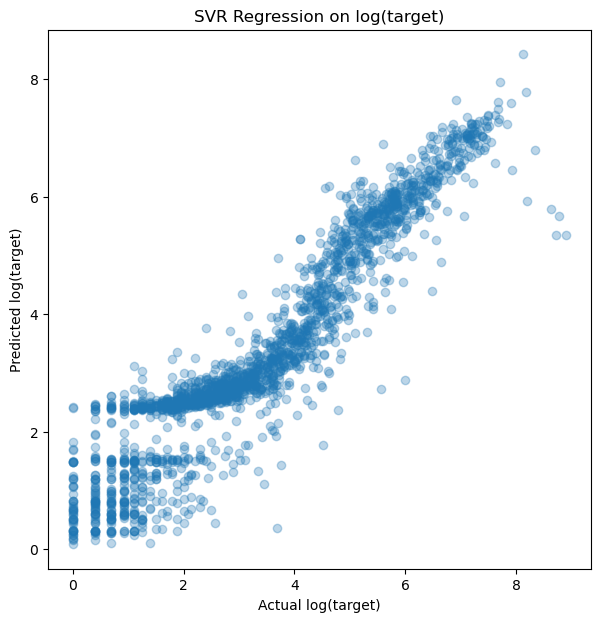

In [3]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_log, alpha=0.3)
plt.xlabel("Actual log(target)")
plt.ylabel("Predicted log(target)")
plt.title("SVR Regression on log(target)")
plt.show()